In [1]:
pip install antspyx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 38.6 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


Loading subject data...
Running N4 bias correction...
Cropping neck (fraction=0.25)...
Downsampling to (2, 2, 2)mm for SyN computation...
Registering T1 -> MNI (SyN, downsampled)... 


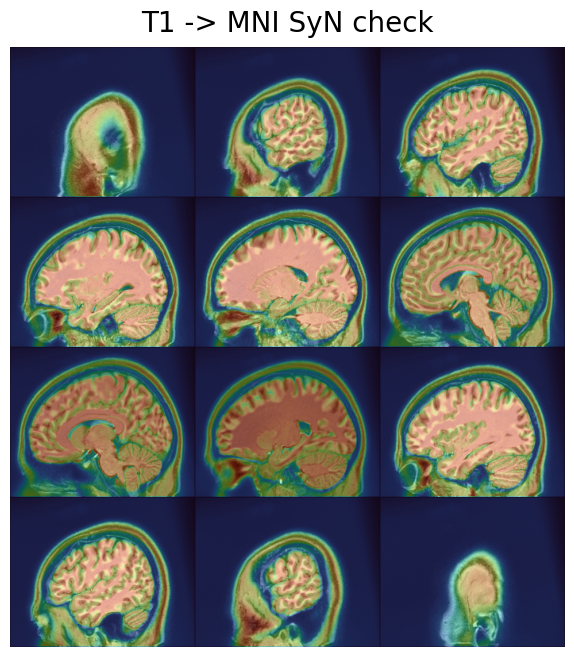

Registering EPI -> T1 (BOLDRigid)...


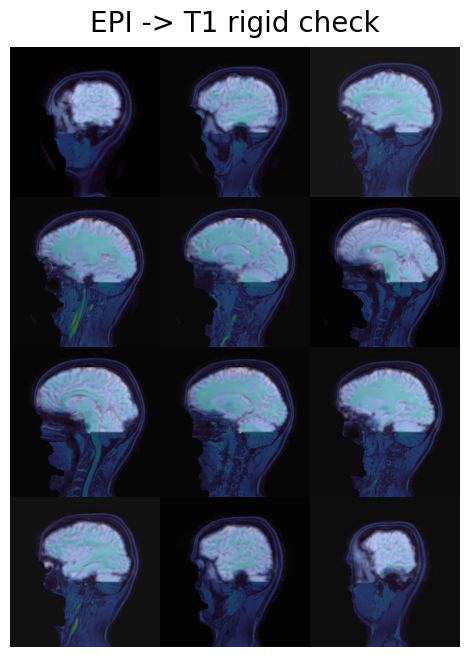

Applying composed transform to 4D EPI run (volume-by-volume, memory-safe)...
Source BOLD dtype: int16 -- output will match this.
  volume 1/156
  volume 11/156
  volume 21/156
  volume 31/156
  volume 41/156
  volume 51/156
  volume 61/156
  volume 71/156
  volume 81/156
  volume 91/156
  volume 101/156
  volume 111/156
  volume 121/156
  volume 131/156
  volume 141/156
  volume 151/156
Preserved TR = 2.0000009536743164 sec in output header.
Saved: /home/jovyan/analysis/sub-04_run-2_bold_in_mni.nii.gz
Applying composed transform to brain mask...
Saved: /home/jovyan/analysis/sub-04_mask_in_mni.nii.gz
Done.


In [2]:
"""
Full pipeline for sub-04, run-1: T1 skull-strip + T1->MNI SyN + EPI->T1 rigid,
composed and applied to the EPI 4D data and brain mask.

Memory-conscious version: downsamples for the SyN step, uses SyNQuick,
and caps ITK thread count -- tuned for a ~16GB pod limit.
"""

import os
# set BEFORE importing ants -- caps thread-related memory blowup
os.environ["ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS"] = "2"

import ants
from nilearn.datasets import fetch_icbm152_2009, load_mni152_brain_mask
import nibabel as nib

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
ANALYSIS_DIR = "/home/jovyan/analysis"
SUB = "04"
RUN = 2
CROP_FRACTION = 0.25  # fraction of axis 1 to trim from the neck end -- tune per subject
SYN_RESAMPLE_MM = (2, 2, 2)  # downsample resolution used ONLY for computing the SyN transform

T1_PATH = f"{ANALYSIS_DIR}/sub-{SUB}_T1w.nii.gz"
MASK_PATH = f"{ANALYSIS_DIR}/sub-{SUB}_brain_mask.nii.gz"
BOLD_PATH = f"{ANALYSIS_DIR}/sub-{SUB}_task-objectcategories_run-{RUN}_bold.nii.gz"

MNI_HEAD_PATH = f"{ANALYSIS_DIR}/mni152_head_full.nii.gz"
MNI_MASK_PATH = f"{ANALYSIS_DIR}/mni152_brain_mask.nii.gz"

OUT_EPI_MNI = f"{ANALYSIS_DIR}/sub-{SUB}_run-{RUN}_bold_in_mni.nii.gz"
OUT_MASK_MNI = f"{ANALYSIS_DIR}/sub-{SUB}_mask_in_mni.nii.gz"

# ---------------------------------------------------------------------------
# Step 0: make sure MNI templates exist (whole head + skull-stripped mask)
# ---------------------------------------------------------------------------
if not os.path.exists(MNI_HEAD_PATH):
    print("Fetching whole-head MNI template...")
    icbm = fetch_icbm152_2009()
    t1_whole_head_nib = nib.load(icbm["t1"])
    nib.save(t1_whole_head_nib, MNI_HEAD_PATH)

if not os.path.exists(MNI_MASK_PATH):
    print("Fetching MNI brain mask...")
    mni_mask_nib = load_mni152_brain_mask(resolution=1)
    nib.save(mni_mask_nib, MNI_MASK_PATH)

t1_whole_head_ap = ants.image_read(MNI_HEAD_PATH)
mni_mask_ap = ants.image_read(MNI_MASK_PATH)

# Output grid for the *final* resampled EPI/mask: keep this at the EPI's native
# 2.5mm iso resolution instead of the full-res (~1mm) MNI template. Using
# t1_whole_head_ap directly as `fixed` in apply_transforms below is what was
# silently upsampling everything to 1mm.
OUTPUT_RESAMPLE_MM = (2.5, 2.5, 2.5)
mni_ref_2p5 = ants.resample_image(t1_whole_head_ap, OUTPUT_RESAMPLE_MM, use_voxels=False)

# ---------------------------------------------------------------------------
# Step 1: load subject data
# ---------------------------------------------------------------------------
print("Loading subject data...")
t1_raw = ants.image_read(T1_PATH)
brain_mask_04 = ants.image_read(MASK_PATH)  # subject's native bold3Tp2-space mask
bold_04 = ants.image_read(BOLD_PATH)
bold_04_vol0 = ants.slice_image(bold_04, axis=3, idx=0)

# ---------------------------------------------------------------------------
# Step 2: N4 bias field correction
# ---------------------------------------------------------------------------
print("Running N4 bias correction...")
brain_t1_n4_04 = ants.n4_bias_field_correction(t1_raw)

# ---------------------------------------------------------------------------
# Step 3: crop the neck out (axis 1, trim from the start)
# ---------------------------------------------------------------------------
print(f"Cropping neck (fraction={CROP_FRACTION})...")
shape = brain_t1_n4_04.shape
crop_start = [0, 0, 0]
crop_start[1] = int(shape[1] * CROP_FRACTION)
crop_end = list(shape)
t1_cropped = ants.crop_indices(brain_t1_n4_04, crop_start, crop_end)

# free the raw T1 reference, no longer needed
del t1_raw

# ---------------------------------------------------------------------------
# Step 4: T1 -> MNI, SyNQuick, computed at DOWNSAMPLED resolution
# ---------------------------------------------------------------------------
print(f"Downsampling to {SYN_RESAMPLE_MM}mm for SyN computation...")
t1_cropped_ds = ants.resample_image(t1_cropped, SYN_RESAMPLE_MM, use_voxels=False)
t1_whole_head_ds = ants.resample_image(t1_whole_head_ap, SYN_RESAMPLE_MM, use_voxels=False)

print("Registering T1 -> MNI (SyN, downsampled)... ")
syn_reg = ants.registration(
    fixed=t1_whole_head_ds,
    moving=t1_cropped_ds,
    type_of_transform="SyN"
)

del t1_cropped_ds, t1_whole_head_ds  # free downsampled copies once transform is computed

# sanity check plot (full-res warpedmovout not available since we registered downsampled --
# apply the computed transform back onto the full-res cropped T1 for an accurate check)
t1_check = ants.apply_transforms(
    fixed=t1_whole_head_ap, moving=t1_cropped,
    transformlist=syn_reg["fwdtransforms"], interpolator="linear"
)
ants.plot(t1_check, overlay=t1_whole_head_ap, overlay_alpha=0.4, title="T1 -> MNI SyN check")
del t1_check

# ---------------------------------------------------------------------------
# Step 5: EPI -> T1, rigid (uses the FULL uncropped T1)
# ---------------------------------------------------------------------------
print("Registering EPI -> T1 (BOLDRigid)...")
epi_to_t1_reg = ants.registration(
    fixed=brain_t1_n4_04,
    moving=bold_04_vol0,
    type_of_transform="BOLDRigid"
)

ants.plot(epi_to_t1_reg["warpedmovout"], overlay=brain_t1_n4_04, overlay_alpha=0.4,
          title="EPI -> T1 rigid check")

# ---------------------------------------------------------------------------
# Step 6: compose transforms (EPI -> T1 -> MNI) and apply to full 4D EPI
# ---------------------------------------------------------------------------
print("Applying composed transform to 4D EPI run (volume-by-volume, memory-safe)...")
combined_transforms = syn_reg["fwdtransforms"] + epi_to_t1_reg["fwdtransforms"]

import numpy as np
n_vols = bold_04.shape[3]
ref_shape = mni_ref_2p5.shape  # output spatial shape, 2.5mm MNI grid

# Match the ORIGINAL BOLD file's on-disk dtype exactly, rather than assuming
# int16. This matters because the data has both negative and positive values
# (e.g. it's already been detrended/demeaned), so it must be a *signed* type --
# np.int16 is signed by default (range -32768..32767), unlike np.uint16, but we
# still read the true dtype off disk instead of hardcoding it.
BOLD_DTYPE = np.dtype(nib.load(BOLD_PATH).header.get_data_dtype())
dtype_info = np.iinfo(BOLD_DTYPE) if np.issubdtype(BOLD_DTYPE, np.integer) else None
print(f"Source BOLD dtype: {BOLD_DTYPE} -- output will match this.")

# pre-allocate a disk-backed memmap so we never hold the full 4D array in RAM.
# Matching the source's integer dtype keeps this ~4x smaller than float32.
memmap_path = f"{ANALYSIS_DIR}/sub-{SUB}_run-{RUN}_bold_in_mni.dat"
out_memmap = np.memmap(memmap_path, dtype=BOLD_DTYPE, mode="w+",
                        shape=(ref_shape[0], ref_shape[1], ref_shape[2], n_vols))

for t in range(n_vols):
    if t % 10 == 0:
        print(f"  volume {t+1}/{n_vols}")
    vol = ants.slice_image(bold_04, axis=3, idx=t)
    vol_in_mni = ants.apply_transforms(
        fixed=mni_ref_2p5,
        moving=vol,
        transformlist=combined_transforms,
        interpolator="linear"
    )
    # ANTsImage/ITK only supports {unsigned char, unsigned int, float, double} --
    # there's no ITK "short" image type, so we can't cast at the ANTsImage level.
    # Cast the numpy array itself once we pull it out, right before storing.
    arr = vol_in_mni.numpy()
    if dtype_info is not None:
        # linear interpolation shouldn't overshoot the source range, but clip
        # defensively so an edge case wraps/clips loudly-visible rather than
        # silently corrupting values
        clipped = np.clip(arr, dtype_info.min, dtype_info.max)
        if not np.array_equal(clipped, arr):
            print(f"  WARNING: volume {t} had values outside {BOLD_DTYPE} range, clipped")
        arr = clipped
    out_memmap[:, :, :, t] = np.round(arr).astype(BOLD_DTYPE)
    del vol, vol_in_mni  # release each volume before the next iteration

out_memmap.flush()

# Wrap the memmapped array into a proper NIfTI using the 2.5mm grid's own
# affine -- NOT the full-res MNI template's affine, since the voxel size
# (and therefore the affine) differs now.
import nibabel as nib
ref_nii_path = f"{ANALYSIS_DIR}/_mni_ref_2p5_tmp.nii.gz"
ants.image_write(mni_ref_2p5, ref_nii_path)
ref_affine = nib.load(ref_nii_path).affine
os.remove(ref_nii_path)

epi_4d_nii = nib.Nifti1Image(np.asarray(out_memmap), affine=ref_affine)
epi_4d_nii.header.set_data_dtype(BOLD_DTYPE)

# Preserve the TR. The affine only carries spatial (x/y/z) voxel size --
# it says nothing about the 4th dimension, so pixdim[4]/TR defaults to 1.0
# unless we set it explicitly from the source file.
src_header = nib.load(BOLD_PATH).header
src_zooms = src_header.get_zooms()
if len(src_zooms) > 3:
    TR = src_zooms[3]
    sx, sy, sz = epi_4d_nii.header.get_zooms()[:3]
    epi_4d_nii.header.set_zooms((sx, sy, sz, TR))
    xyz_unit, t_unit = src_header.get_xyzt_units()
    epi_4d_nii.header.set_xyzt_units(xyz_unit, t_unit)
    print(f"Preserved TR = {TR} {t_unit} in output header.")
else:
    print("WARNING: could not find a TR in the source BOLD header -- not set on output.")

nib.save(epi_4d_nii, OUT_EPI_MNI)
del out_memmap, epi_4d_nii
os.remove(memmap_path)  # clean up the raw .dat scratch file, keep only the .nii.gz
print(f"Saved: {OUT_EPI_MNI}")

# ---------------------------------------------------------------------------
# Step 7: apply the same composed transform to the subject's brain mask
# ---------------------------------------------------------------------------
print("Applying composed transform to brain mask...")
mask_in_mni = ants.apply_transforms(
    fixed=mni_ref_2p5,
    moving=brain_mask_04,
    transformlist=combined_transforms,
    interpolator="nearestNeighbor"
).clone(brain_mask_04.pixeltype)  # keep the mask's original integer dtype
ants.image_write(mask_in_mni, OUT_MASK_MNI)
print(f"Saved: {OUT_MASK_MNI}")

print("Done.")